# **Machine Learning on Big Data (CN7030) CRWK 23-24 Term B [60% weighting]**
# **Group ID: [:(]**
1.   Student 1: Jadyn Vigil, 2579155
2.   Student 2: Franciszek Ostwald, 1914016
3.   Student 3: Name and ID

---

If you want to add comments on your group work, please write it here for us:


# **Initiate and Configure Spark**

In [ ]:
!pip install pyspark


In [ ]:
from pyspark.sql import SparkSession
spark=SparkSession.builder \
                    .config("spark.executor.memory", "12g") \
                    .config("spark.driver.memory", "12g") \
                    .config("spark.driver.maxResultSize", "12g") \
                    .appName('GroupWork').getOrCreate()

---
# **Task 1 -Data Loading and Preprocessing (15 marks)**
---


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=spark.read.csv("/content/drive/MyDrive/Files/original_cleaned_nyc_taxi_data_2018.csv",inferSchema=True,header=True)
df.show()

+---+-------------+---------+------------------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+------------------+-----------------------+
|_c0|trip_distance|rate_code|store_and_fwd_flag|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|imp_surcharge|total_amount|pickup_location_id|dropoff_location_id|year|month|day|day_of_week|hour_of_day|     trip_duration|calculated_total_amount|
+---+-------------+---------+------------------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+------------------+-----------------------+
|  3|        16.97|        1|                 N|           1|       49.5|  0.0|    0.5|      5.61|        5.76|          0.3|       61.67|               231|                138|2018|    3| 29|          3|         13|    

In [ ]:
print(df.count())
print(df.rdd.getNumPartitions())

8319928
6


In [ ]:
# df = df.repartition(4)
# df.rdd.getNumPartitions()

**Jadyn Vigil - PRE-PROCESSING ################################**

In [ ]:
df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- rate_code: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- imp_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- pickup_location_id: integer (nullable = true)
 |-- dropoff_location_id: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- hour_of_day: integer (nullable = true)
 |-- trip_duration: double (nullable = true)
 |-- calculated_total_amount: double (nullable = true)



The schema is checked to make sure there aren't any strings.

In [ ]:
#Check for missing values
from pyspark.sql.functions import col, sum

# Calculate the number of null values in each column
missing_values = [sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]

# Show values missing
values_missing = df.select(missing_values)
values_missing.show()

+---+-------------+---------+------------------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+-------------+-----------------------+
|_c0|trip_distance|rate_code|store_and_fwd_flag|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|imp_surcharge|total_amount|pickup_location_id|dropoff_location_id|year|month|day|day_of_week|hour_of_day|trip_duration|calculated_total_amount|
+---+-------------+---------+------------------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+-------------+-----------------------+
|  0|            0|        0|                 0|           0|          0|    0|      0|         0|           0|            0|           0|                 0|                  0|   0|    0|  0|          0|          0|            0|     

Missing values are checked for each column. The only column with missing values is the calculated_total_amount column.

In [ ]:
# drop columns
final_df = df.drop("_c0", "rate_code", "store_and_fwd_flag","payment_type", "pickup_location_id", "dropoff_location_id", "year", "month", "day", "day_of_week", "hour_of_day", "trip_duration", "calculated_total_amount")
final_df.show(10)

+-------------+-----------+-----+-------+----------+------------+-------------+------------+
|trip_distance|fare_amount|extra|mta_tax|tip_amount|tolls_amount|imp_surcharge|total_amount|
+-------------+-----------+-----+-------+----------+------------+-------------+------------+
|        16.97|       49.5|  0.0|    0.5|      5.61|        5.76|          0.3|       61.67|
|        14.45|       45.5|  0.0|    0.5|     10.41|        5.76|          0.3|       62.47|
|         11.6|       42.0|  0.0|    0.5|     14.57|        5.76|          0.3|       63.13|
|          5.1|       26.5|  1.0|    0.5|      5.65|         0.0|          0.3|       33.95|
|        11.11|       45.5|  1.0|    0.5|     10.61|        5.76|          0.3|       63.67|
|         9.54|       41.0|  1.0|    0.5|      9.71|        5.76|          0.3|       58.27|
|         10.0|       38.5|  1.0|    0.5|      8.05|         0.0|          0.3|       48.35|
|          9.8|       38.5|  1.0|    0.5|      6.94|        5.76|     

I dropped the selected columns because they weren't relevant contributing features to calculating the total amount or to the price prediction task using regression models. The calculated_total_amount column was dropped due to the missing values, the total_amount column will be used as the labeled column.

In [ ]:
from pyspark.ml.feature import VectorAssembler

# combine features into a single vector column using VectorAssembler
assembler = VectorAssembler(inputCols=["trip_distance", "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount", "imp_surcharge"],
                            outputCol="features")

# Apply VectorAssembler to final_df to show one input column and one output column
dataset = assembler.transform(final_df)

# Select only the "features" and "total_amount" column to predict
dataset = dataset.select("features", "total_amount")

# Show the first 5 rows of the DataFrame, see all records without truncation
dataset.show(5, truncate=False)

+-----------------------------------+------------+
|features                           |total_amount|
+-----------------------------------+------------+
|[16.97,49.5,0.0,0.5,5.61,5.76,0.3] |61.67       |
|[14.45,45.5,0.0,0.5,10.41,5.76,0.3]|62.47       |
|[11.6,42.0,0.0,0.5,14.57,5.76,0.3] |63.13       |
|[5.1,26.5,1.0,0.5,5.65,0.0,0.3]    |33.95       |
|[11.11,45.5,1.0,0.5,10.61,5.76,0.3]|63.67       |
+-----------------------------------+------------+
only showing top 5 rows



I combined the selected features to contribute to the price prediction into a features column, and am using the total_amount as the labeled column.

In [ ]:
from pyspark.ml.feature import StandardScaler

# Normalize the data by scaling
scaler = StandardScaler(inputCol = 'features', outputCol = 'scaledFeatures')

# Fit the scaler to the data and transform the features
scaler_model = scaler.fit(dataset)
data_scaled = scaler_model.transform(dataset)

data_scaled = data_scaled.select('scaledFeatures', 'total_amount')
data_scaled.show(5, truncate = False)

+-----------------------------------------------------------------------------------------------------------------------------------+------------+
|scaledFeatures                                                                                                                     |total_amount|
+-----------------------------------------------------------------------------------------------------------------------------------+------------+
|[2.884850263598151,0.6539783410641749,0.0,6.043060556946095,1.227546659284149,1.5353832540051882,80.12909813820313]                |61.67       |
|[2.456457649321938,0.6011316064327263,0.0,6.043060556946095,2.277853961345453,1.5353832540051882,80.12909813820313]                |62.47       |
|[1.9719660022238394,0.5548907136302089,0.0,6.043060556946095,3.188120289798583,1.5353832540051882,80.12909813820313]               |63.13       |
|[0.8669850527018603,0.35010961693334613,1.766231153223802,6.043060556946095,1.2362992201346599,0.0,80.12909813820313]

The StandardScaler feature was used to normalize the data. It will keep the values around the mean and consider standard deviation. I fit the data which will compute the mean and standard deviation and store scaling parameters. I transformed the data which will scale the features of the data using parameters learned during fitting.

In [ ]:
# split data
train_data, test_data = data_scaled.randomSplit([0.7, 0.3], seed = 21)
train_data.show(5, truncate = False)

+-----------------------------------------------------+------------+
|scaledFeatures                                       |total_amount|
+-----------------------------------------------------+------------+
|(7,[0,1],[0.003399941383144551,0.03302920914465529]) |2.5         |
|(7,[0,1],[0.006799882766289102,0.9644529070239346])  |73.0        |
|(7,[0,1],[0.008499853457861377,0.792701019471727])   |60.0        |
|(7,[0,1],[0.016999706915722754,0.039635050973586355])|3.0         |
|(7,[0,1],[1.6829709846565526,0.9520339243855442])    |72.06       |
+-----------------------------------------------------+------------+
only showing top 5 rows



70% of the data will go to training, and 30% will go to testing.

**Franciszek Ostwald - PRE-PROCESSING ################################**

In [ ]:
df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- rate_code: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- imp_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- pickup_location_id: integer (nullable = true)
 |-- dropoff_location_id: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- hour_of_day: integer (nullable = true)
 |-- trip_duration: double (nullable = true)
 |-- calculated_total_amount: double (nullable = true)



I check the types of the columns. We can't have strings but there is only one column that is string and that column is not really needed, so I will drop it and then I don't need to use StringIndexer to convert any columns.

In [ ]:
df2 = df.drop("calculated_total_amount", "store_and_fwd_flag", "_c0")
df2.show(5)

+-------------+---------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+-------------+
|trip_distance|rate_code|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|imp_surcharge|total_amount|pickup_location_id|dropoff_location_id|year|month|day|day_of_week|hour_of_day|trip_duration|
+-------------+---------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+-------------+
|        16.97|        1|           1|       49.5|  0.0|    0.5|      5.61|        5.76|          0.3|       61.67|               231|                138|2018|    3| 29|          3|         13|       3317.0|
|        14.45|        1|           1|       45.5|  0.0|    0.5|     10.41|        5.76|          0.3|       62.47|                87|                138|2018|    3| 29

I dropped the columns that I think are not needed.

In [ ]:
#Check for missing values
from pyspark.sql.functions import col, sum

# Check if we have null values
missing_values = [sum(col(c).isNull().cast("int")).alias(c) for c in df2.columns]
missing_values_checked = df2.select(missing_values)
missing_values_checked.show()

+-------------+---------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+-------------+
|trip_distance|rate_code|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|imp_surcharge|total_amount|pickup_location_id|dropoff_location_id|year|month|day|day_of_week|hour_of_day|trip_duration|
+-------------+---------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+-------------+
|            0|        0|           0|          0|    0|      0|         0|           0|            0|           0|                 0|                  0|   0|    0|  0|          0|          0|            0|
+-------------+---------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---

I checked for missing values in all columns. There are none, so I don't have to deal with dropping null values.

In [ ]:
df3,df4 = df2.randomSplit([0.1, 0.9],seed=1234)

I splitted the dataset into two datasets. 10% and 90% of the original dataset. I will use the first one, for 10% of the dataset. This step is mandatory as having too large dataset will not allow me convert toPandas later on.

In [ ]:
print(df3.count())

831667


I made sure that the dataset is now 10%.

In [ ]:
from pyspark.ml.feature import VectorAssembler
input_cols=['trip_distance', 'tip_amount', 'tolls_amount', 'total_amount', 'pickup_location_id', 'dropoff_location_id', 'hour_of_day', 'month', 'day_of_week', 'trip_duration',
            'rate_code', 'payment_type', 'fare_amount', 'extra', 'mta_tax']
# Transform all features into a vector using VectorAssembler
vec_assembler = VectorAssembler(inputCols = input_cols, outputCol='features')
df_final = vec_assembler.transform(df3)
df_final.show()

+-------------+---------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+------------------+--------------------+
|trip_distance|rate_code|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|imp_surcharge|total_amount|pickup_location_id|dropoff_location_id|year|month|day|day_of_week|hour_of_day|     trip_duration|            features|
+-------------+---------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+------------------+--------------------+
|         0.01|        1|           1|        2.5|  0.0|    0.5|       0.5|         0.0|          0.3|        5.75|               144|                144|2018|    8|  5|          6|         10|            2348.0|[0.01,0.5,0.0,5.7...|
|         0.01|        1|           1|        2.5|  0.0|    0.5|

I used vector assembler to create a vector of combined values from all the columns. I named it features. I will use this column to implement a model and make predictions.

---
# **Task 2 - Model Selection and Implementation (25 marks)**
---


**Jadyn Vigil - Model Selection and Implementation ###########################**

In [ ]:
from pyspark.ml.regression import LinearRegression

# Apply Linear Regression
lr = LinearRegression(labelCol = 'total_amount', featuresCol = 'scaledFeatures', predictionCol = 'prediction')

# Fit the model to the training data
lr_model = lr.fit(train_data)

# Make prediction on the test data using transform
lr_predictions = lr_model.transform(test_data)

lr_predictions.select('prediction', 'total_amount').show(10, truncate = False)

+------------------+------------+
|prediction        |total_amount|
+------------------+------------+
|45.85694523563021 |45.85       |
|56.46636085573803 |56.46       |
|67.25598305493278 |67.25       |
|65.30587898322983 |65.3        |
|96.98575809650276 |96.98       |
|70.26578657092618 |70.26       |
|73.06577431926492 |73.06       |
|70.26574826090093 |70.26       |
|117.35552549462263|117.35      |
|60.50353141329312 |60.5        |
+------------------+------------+
only showing top 10 rows



When applying linear regression, the labeled column shows what will be predicted, the features are the scaled features, and the prediction column will show the mathematical results. The training data is being fit to learn and calculate beta0 and beta1. The test data is transformed to apply the learning and make predictions.

In [ ]:
#Access the coefficients and intercept of the model

coefficients = lr_model.coefficients
intercept = lr_model.intercept

print(coefficients)
print(intercept)

[-0.00045071394966665753,75.69045601860002,0.5654997929993214,0.0821316680769739,4.571820353421394,3.7507155669407193,0.003801552090787258]
0.007303885437329494


This showed me that the predictor =

total_amount = 0.007303885437329494 + -0.00045071394966665753 (TRIP DISTANCE) + 75.69045601860002 (IMP SURCHARGE) + ..........

This can be used if any further data is entered to predict the total amount.

**Franciszek Ostwald - Model Selection and Implementation ####################**

## K-Means

In [ ]:
from pyspark.ml.clustering import KMeans

kmeans= KMeans(featuresCol = "features", k=5)
model=kmeans.fit(df_final)

I implemented the model using K-Means. I specified to use 5 clusters and I fitted the model to the dataset.

In [ ]:
model.transform(df_final).groupBy("prediction").count().show()

+----------+------+
|prediction| count|
+----------+------+
|         1|  2630|
|         3|409659|
|         4|   315|
|         2|318998|
|         0|100065|
+----------+------+



I checked how many data in each cluster.

## BisectingKMeans

In [ ]:
from pyspark.ml.clustering import BisectingKMeans

# Trains a bisecting k-means model.
bkm = BisectingKMeans().setK(5).setSeed(1)
bkm_model = bkm.fit(df_final)

# Evaluate clustering.
cost = bkm_model.computeCost(df_final)
print("Within Set Sum of Squared Errors = " + str(cost))

# Shows the result.
print("Cluster Centers: ")
centers = bkm_model.clusterCenters()
for center in centers:
    print(center)

/usr/local/lib/python3.10/dist-packages/pyspark/ml/clustering.py:1016: FutureWarning: Deprecated in 3.0.0. It will be removed in future versions. Use ClusteringEvaluator instead. You can also get the cost on the training dataset in the summary.
  warnings.warn(


Within Set Sum of Squared Errors = 384787290515.39136
Cluster Centers: 
[9.03843762e+00 5.53776345e+00 2.16618799e+00 4.03640464e+01
 1.53205825e+02 1.47667548e+02 1.38378432e+01 6.45790979e+00
 2.95206813e+00 8.89811726e+02 1.15384659e+00 1.17611169e+00
 3.15153693e+01 3.47786675e-01 4.88413591e-01]
[9.13292030e+00 5.54307546e+00 2.18758239e+00 4.06652007e+01
 1.52868518e+02 1.47864544e+02 1.38090985e+01 6.46874472e+00
 2.95071937e+00 1.76442212e+03 1.15476520e+00 1.17939694e+00
 3.17917362e+01 3.45957408e-01 4.88183956e-01]
[9.15002836e+00 5.49132678e+00 2.18020448e+00 4.06350732e+01
 1.53083581e+02 1.47641778e+02 1.38071876e+01 6.46101258e+00
 2.94632330e+00 2.95064971e+03 1.15695597e+00 1.18508786e+00
 3.18175895e+01 3.48223719e-01 4.88662910e-01]
[8.87272727e+00 5.71515152e+00 1.75593939e+00 3.96753333e+01
 1.55587879e+02 1.51812121e+02 1.46666667e+01 6.42424242e+00
 2.94545455e+00 5.45586970e+04 1.09090909e+00 1.16363636e+00
 3.10681818e+01 3.30303030e-01 4.93939394e-01]
[9.22750

I also implemented the model using BisectingKMeans with also 5 clusters.

In [ ]:
bkm_model.transform(df_final).groupBy("prediction").count().show()

+----------+------+
|prediction| count|
+----------+------+
|         1|408619|
|         3|   165|
|         4|  2602|
|         2|245074|
|         0|175207|
+----------+------+



I checked how many data in each cluster with this model. It is quite simillar, just a little different from KMeans.

---
# **Task 3 - Model Parameter Tuning (20 marks)**
---


**Jadyn Vigil - Model Parameter Tuning ###########################**

In [ ]:
# Apply Lasso Regression
lasso = LinearRegression(labelCol = 'total_amount', featuresCol = 'scaledFeatures',
                         predictionCol = 'prediction', elasticNetParam = 1.0, regParam = 0.08) # lambda: tuning
lasso_model = lasso.fit(train_data)
lasso_predictions = lasso_model.transform(test_data)

lasso_predictions.select('prediction', 'total_amount').show(10, truncate = False)

+------------------+------------+
|prediction        |total_amount|
+------------------+------------+
|46.78928132227141 |45.85       |
|57.38318300433788 |56.46       |
|68.15681157639227 |67.25       |
|66.20977026818967 |65.3        |
|97.84170290606579 |96.98       |
|71.16224457007937 |70.26       |
|73.95799619211387 |73.06       |
|71.16224457007937 |70.26       |
|118.18079595636681|117.35      |
|60.9178118407672  |60.5        |
+------------------+------------+
only showing top 10 rows



I originally had the lambda tuning set to 0.15, but the results were not great. Through trial and error I decided to keep lambda tuning set at 0.08.

In [ ]:
# Ridge
ridge = LinearRegression(labelCol = 'total_amount', featuresCol = 'scaledFeatures',
                         predictionCol = 'prediction', elasticNetParam = 0.0, regParam = 0.08)
ridge_model = ridge.fit(train_data)
ridge_predictions = ridge_model.transform(test_data)
ridge_predictions.select('prediction', 'total_amount').show(10, truncate = False)

+------------------+------------+
|prediction        |total_amount|
+------------------+------------+
|45.94203562564247 |45.85       |
|56.56467148205804 |56.46       |
|67.35501001696201 |67.25       |
|65.41490932030548 |65.3        |
|97.03878366800255 |96.98       |
|70.37036888998053 |70.26       |
|73.16549886350602 |73.06       |
|70.37258292372735 |70.26       |
|117.38164578178241|117.35      |
|60.49580037239025 |60.5        |
+------------------+------------+
only showing top 10 rows



I originally had lambda tuning set to 0.15, but the results were not great. Through trial and error I decided to keep lambda tuning set at 0.08.

**Franciszek Ostwald - Model Parameter Tuning ###########################**

In [ ]:
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.clustering import KMeans
silhouette_score=[]
evaluator = ClusteringEvaluator(predictionCol='prediction', featuresCol='features', \
                                metricName='silhouette', distanceMeasure='squaredEuclidean')
for i in range(2,20):
    kmeans=KMeans(featuresCol='features', k=i)
    model=kmeans.fit(df_final)
    prediction=model.transform(df_final)
    score=evaluator.evaluate(prediction)
    silhouette_score.append(score)
    print('Silhouette Score for k =',i,'is',score)


Silhouette Score for k = 2 is 0.9995389517646898
Silhouette Score for k = 3 is 0.6382186254666913
Silhouette Score for k = 4 is 0.5845929425108374
Silhouette Score for k = 5 is 0.6237362068230343
Silhouette Score for k = 6 is 0.6283810803466072
Silhouette Score for k = 7 is 0.6724203659856163
Silhouette Score for k = 8 is 0.6710664634575312
Silhouette Score for k = 9 is 0.6540317062302528
Silhouette Score for k = 10 is 0.6530169005461739
Silhouette Score for k = 11 is 0.6469500561360765
Silhouette Score for k = 12 is 0.6459460931259993
Silhouette Score for k = 13 is 0.6406949350673533
Silhouette Score for k = 14 is 0.6273740840220198
Silhouette Score for k = 15 is 0.6233895167844113
Silhouette Score for k = 16 is 0.613613411552189
Silhouette Score for k = 17 is 0.6123723016404881
Silhouette Score for k = 18 is 0.612934791953503
Silhouette Score for k = 19 is 0.5784458248762712


I used Silhoutte Score technique to determine what is the ideal number of clusters with this dataset. I am checking between 2 and 20 clusters. This tells me how well each data point fits into its cluster and doesn't fit nicely with other clusters. The result here is clear that I should use 2 clusters as the score is 0.9995.

In [ ]:
kmeans= KMeans(featuresCol = "features", k=2)
model=kmeans.fit(df_final)
model.transform(df_final).groupBy("prediction").count().show()

+----------+------+
|prediction| count|
+----------+------+
|         1|828900|
|         0|  2767|
+----------+------+



Then I implemented KMeans model with 2 clusters and checked how many data points in each cluster. It looks like most of the data is in one cluster and just a small part is in the other one. I think it is because our dataset is not ideal for clustering as all datapoints are quite similar to each other.

In [ ]:
kmeans= KMeans(featuresCol = "features", k=7)
model=kmeans.fit(df_final)
model.transform(df_final).groupBy("prediction").count().show()

+----------+------+
|prediction| count|
+----------+------+
|         1|  2626|
|         6|117606|
|         3|335986|
|         5| 21066|
|         4|   312|
|         2|304705|
|         0| 49366|
+----------+------+



Because 2 clusters were very unbalanced, I also tried 7 clusters which had 0.67 score. That is not the best score but I just wanted to viusalize more clusters so I can compare them.

In [ ]:
from pyspark.ml.clustering import BisectingKMeans

# Trains a bisecting k-means model.
bkm = BisectingKMeans().setK(2).setSeed(1)
bkm_model = bkm.fit(df_final)

# Evaluate clustering.
cost = bkm_model.computeCost(df_final)
print("Within Set Sum of Squared Errors = " + str(cost))

# Shows the result.
print("Cluster Centers: ")
centers = bkm_model.clusterCenters()
for center in centers:
    print(center)

bkm_model.transform(df_final).groupBy("prediction").count().show()

/usr/local/lib/python3.10/dist-packages/pyspark/ml/clustering.py:1016: FutureWarning: Deprecated in 3.0.0. It will be removed in future versions. Use ClusteringEvaluator instead. You can also get the cost on the training dataset in the summary.
  warnings.warn(


Within Set Sum of Squared Errors = 983668377281.035
Cluster Centers: 
[9.11795178e+00 5.52668443e+00 2.18096945e+00 4.05924258e+01
 1.53003267e+02 1.47755873e+02 1.38145747e+01 6.46419230e+00
 2.94966824e+00 1.93060486e+03 1.15520811e+00 1.18038364e+00
 3.17406249e+01 3.47014465e-01 4.88374376e-01]
[9.20634622e+00 5.60298880e+00 2.57087821e+00 4.13872570e+01
 1.54283339e+02 1.46302132e+02 1.39656668e+01 6.41705819e+00
 2.95735454e+00 8.30315493e+04 1.15540296e+00 1.17961691e+00
 3.20945067e+01 3.27069028e-01 4.86989519e-01]
+----------+------+
|prediction| count|
+----------+------+
|         1|  2767|
|         0|828900|
+----------+------+



I also implemented Bisecting KMeans model with two clusters and check how many data points in each cluster. Looks like clusters are identical to KMeans.

In [ ]:
# Trains a bisecting k-means model.
bkm = BisectingKMeans().setK(7).setSeed(1)
bkm_model = bkm.fit(df_final)

# Evaluate clustering.
cost = bkm_model.computeCost(df_final)
print("Within Set Sum of Squared Errors = " + str(cost))

# Shows the result.
print("Cluster Centers: ")
centers = bkm_model.clusterCenters()
for center in centers:
    print(center)

bkm_model.transform(df_final).groupBy("prediction").count().show()

/usr/local/lib/python3.10/dist-packages/pyspark/ml/clustering.py:1016: FutureWarning: Deprecated in 3.0.0. It will be removed in future versions. Use ClusteringEvaluator instead. You can also get the cost on the training dataset in the summary.
  warnings.warn(


Within Set Sum of Squared Errors = 280424114157.5427
Cluster Centers: 
[9.03843762e+00 5.53776345e+00 2.16618799e+00 4.03640464e+01
 1.53205825e+02 1.47667548e+02 1.38378432e+01 6.45790979e+00
 2.95206813e+00 8.89811726e+02 1.15384659e+00 1.17611169e+00
 3.15153693e+01 3.47786675e-01 4.88413591e-01]
[9.13292030e+00 5.54307546e+00 2.18758239e+00 4.06652007e+01
 1.52868518e+02 1.47864544e+02 1.38090985e+01 6.46874472e+00
 2.95071937e+00 1.76442212e+03 1.15476520e+00 1.17939694e+00
 3.17917362e+01 3.45957408e-01 4.88183956e-01]
[9.15313151e+00 5.50475702e+00 2.18291502e+00 4.06616545e+01
 1.53086286e+02 1.47583918e+02 1.38070442e+01 6.46534834e+00
 2.94479815e+00 2.70551115e+03 1.15623111e+00 1.18397961e+00
 3.18283267e+01 3.47748029e-01 4.88792849e-01]
[9.12762247e+00 5.40150375e+00 2.16428291e+00 4.04500961e+01
 1.53061794e+02 1.48001739e+02 1.38072483e+01 6.43237089e+00
 2.95566238e+00 4.61406186e+03 1.16156984e+00 1.19253028e+00
 3.17362310e+01 3.51443661e-01 4.87792922e-01]
[8.872727

I also checked 7 clusters with Bisecting KMeans model.

As the part of the model parameter tuning I used two different models KMeans and Bisecting KMeans to see different results and compare them with each other.

---
# **Task 4 - Model Evaluation and Accuracy Calculation (20 marks)**
---

**Jadyn Vigil - Model Evaluation and Accuracy Calculation ####################**

In [ ]:
from pyspark.ml.evaluation import RegressionEvaluator

# calculate MSE - Mean Squared Error
evaluator_mse = RegressionEvaluator(labelCol = 'total_amount', predictionCol = 'prediction', metricName = 'mse')
mse1 = evaluator_mse.evaluate(lr_predictions)
mse2 = evaluator_mse.evaluate(lasso_predictions)
mse3 = evaluator_mse.evaluate(ridge_predictions)

# calculate RMSE - Root of MSE
evaluator_rmse = RegressionEvaluator(labelCol = 'total_amount', predictionCol = 'prediction', metricName = 'rmse')
rmse1 = evaluator_rmse.evaluate(lr_predictions)
rmse2 = evaluator_rmse.evaluate(lasso_predictions)
rmse3 = evaluator_rmse.evaluate(ridge_predictions)

# calculate Root squared
evaluator_r2 = RegressionEvaluator(labelCol = 'total_amount', predictionCol = 'prediction', metricName = 'r2')
r2_mse1 = evaluator_r2.evaluate(lr_predictions)
r2_mse2 = evaluator_r2.evaluate(lasso_predictions)
r2_mse3 = evaluator_r2.evaluate(ridge_predictions)

In [ ]:
print('Linear - MSE: ', mse1, ', RMSE: ', rmse1, ', R^2: ', r2_mse1)
print('Lasso - MSE: ', mse2, ', RMSE: ', rmse2, ', R^2: ', r2_mse2)
print('Ridge - MSE: ', mse3, ', RMSE: ', rmse3, ', R^2: ', r2_mse3)

Linear - MSE:  0.0215439025742994 , RMSE:  0.14677841317543736 , R^2:  0.9999985222109227
Lasso - MSE:  0.07552638193691483 , RMSE:  0.2748206359371778 , R^2:  0.9999948193201352
Ridge - MSE:  0.07285183598182052 , RMSE:  0.2699107926367905 , R^2:  0.9999950027787627


I calculated the accuracy using Mean Squared Error, Root of MSE, and Root Squared MSE. The results show that Linear Regression has the best results in terms of MSE, RMSE, and R Squared.

**Franciszek Ostwald - Model Evaluation and Accuracy Calculation #############**

In [ ]:
# 2 clusters kmeans
predictions1=model.transform(df_final)
predictions1.show()

+-------------+---------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+------------------+--------------------+----------+
|trip_distance|rate_code|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|imp_surcharge|total_amount|pickup_location_id|dropoff_location_id|year|month|day|day_of_week|hour_of_day|     trip_duration|            features|prediction|
+-------------+---------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+------------------+--------------------+----------+
|         0.01|        1|           1|        2.5|  0.0|    0.5|       0.5|         0.0|          0.3|        5.75|               144|                144|2018|    8|  5|          6|         10|            2348.0|[0.01,0.5,0.0,5.7...|         1|
|         0.01|     

In [ ]:
pandas_df1 = predictions1.toPandas()
pandas_df1.head()

,trip_distance,rate_code,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id,year,month,day,day_of_week,hour_of_day,trip_duration,features,prediction
0,0.01,1,1,2.5,0.0,0.5,0.50,0.0,0.3,5.75,144,144,2018,8,5,6,10,2348.0,"[0.01, 0.5, 0.0, 5.75, 144.0, 144.0, 10.0, 8.0...",1
1,0.01,1,1,2.5,0.0,0.5,0.50,0.0,0.3,8.75,263,263,2018,6,27,2,11,994.0,"[0.01, 0.5, 0.0, 8.75, 263.0, 263.0, 11.0, 6.0...",1
2,0.01,1,1,2.5,0.0,0.5,0.66,0.0,0.3,3.96,79,79,2018,1,14,6,18,3364.0,"[0.01, 0.66, 0.0, 3.96, 79.0, 79.0, 18.0, 1.0,...",1
3,0.01,1,1,2.5,0.0,0.5,0.66,0.0,0.3,3.96,233,233,2018,1,26,4,7,3586.0,"[0.01, 0.66, 0.0, 3.96, 233.0, 233.0, 7.0, 1.0...",1
4,0.01,1,1,2.5,0.0,0.5,0.66,0.0,0.3,3.96,237,237,2018,12,13,3,9,2175.0,"[0.01, 0.66, 0.0, 3.96, 237.0, 237.0, 9.0, 12....",1


In [ ]:
# 7 clusters kmeans
predictions2=model.transform(df_final)
predictions2.show()

+-------------+---------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+------------------+--------------------+----------+
|trip_distance|rate_code|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|imp_surcharge|total_amount|pickup_location_id|dropoff_location_id|year|month|day|day_of_week|hour_of_day|     trip_duration|            features|prediction|
+-------------+---------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+------------------+--------------------+----------+
|         0.01|        1|           1|        2.5|  0.0|    0.5|       0.5|         0.0|          0.3|        5.75|               144|                144|2018|    8|  5|          6|         10|            2348.0|[0.01,0.5,0.0,5.7...|         2|
|         0.01|     

In [ ]:
pandas_df2 = predictions2.toPandas()
pandas_df2.head()

,trip_distance,rate_code,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id,year,month,day,day_of_week,hour_of_day,trip_duration,features,prediction
0,0.01,1,1,2.5,0.0,0.5,0.50,0.0,0.3,5.75,144,144,2018,8,5,6,10,2348.0,"[0.01, 0.5, 0.0, 5.75, 144.0, 144.0, 10.0, 8.0...",2
1,0.01,1,1,2.5,0.0,0.5,0.50,0.0,0.3,8.75,263,263,2018,6,27,2,11,994.0,"[0.01, 0.5, 0.0, 8.75, 263.0, 263.0, 11.0, 6.0...",3
2,0.01,1,1,2.5,0.0,0.5,0.66,0.0,0.3,3.96,79,79,2018,1,14,6,18,3364.0,"[0.01, 0.66, 0.0, 3.96, 79.0, 79.0, 18.0, 1.0,...",6
3,0.01,1,1,2.5,0.0,0.5,0.66,0.0,0.3,3.96,233,233,2018,1,26,4,7,3586.0,"[0.01, 0.66, 0.0, 3.96, 233.0, 233.0, 7.0, 1.0...",6
4,0.01,1,1,2.5,0.0,0.5,0.66,0.0,0.3,3.96,237,237,2018,12,13,3,9,2175.0,"[0.01, 0.66, 0.0, 3.96, 237.0, 237.0, 9.0, 12....",2


In [ ]:
bkm_predictions1=bkm_model.transform(df_final)
bkm_predictions1.show()

+-------------+---------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+------------------+--------------------+----------+
|trip_distance|rate_code|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|imp_surcharge|total_amount|pickup_location_id|dropoff_location_id|year|month|day|day_of_week|hour_of_day|     trip_duration|            features|prediction|
+-------------+---------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+------------------+--------------------+----------+
|         0.01|        1|           1|        2.5|  0.0|    0.5|       0.5|         0.0|          0.3|        5.75|               144|                144|2018|    8|  5|          6|         10|            2348.0|[0.01,0.5,0.0,5.7...|         0|
|         0.01|     

In [ ]:
pandas_df3 = bkm_predictions1.toPandas()
pandas_df3.head()

,trip_distance,rate_code,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id,year,month,day,day_of_week,hour_of_day,trip_duration,features,prediction
0,0.01,1,1,2.5,0.0,0.5,0.50,0.0,0.3,5.75,144,144,2018,8,5,6,10,2348.0,"[0.01, 0.5, 0.0, 5.75, 144.0, 144.0, 10.0, 8.0...",0
1,0.01,1,1,2.5,0.0,0.5,0.50,0.0,0.3,8.75,263,263,2018,6,27,2,11,994.0,"[0.01, 0.5, 0.0, 8.75, 263.0, 263.0, 11.0, 6.0...",0
2,0.01,1,1,2.5,0.0,0.5,0.66,0.0,0.3,3.96,79,79,2018,1,14,6,18,3364.0,"[0.01, 0.66, 0.0, 3.96, 79.0, 79.0, 18.0, 1.0,...",0
3,0.01,1,1,2.5,0.0,0.5,0.66,0.0,0.3,3.96,233,233,2018,1,26,4,7,3586.0,"[0.01, 0.66, 0.0, 3.96, 233.0, 233.0, 7.0, 1.0...",0
4,0.01,1,1,2.5,0.0,0.5,0.66,0.0,0.3,3.96,237,237,2018,12,13,3,9,2175.0,"[0.01, 0.66, 0.0, 3.96, 237.0, 237.0, 9.0, 12....",0


In [ ]:
bkm_predictions2=bkm_model.transform(df_final)
bkm_predictions2.show()

+-------------+---------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+------------------+--------------------+----------+
|trip_distance|rate_code|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|imp_surcharge|total_amount|pickup_location_id|dropoff_location_id|year|month|day|day_of_week|hour_of_day|     trip_duration|            features|prediction|
+-------------+---------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+------------------+--------------------+----------+
|         0.01|        1|           1|        2.5|  0.0|    0.5|       0.5|         0.0|          0.3|        5.75|               144|                144|2018|    8|  5|          6|         10|            2348.0|[0.01,0.5,0.0,5.7...|         2|
|         0.01|     

In [ ]:
pandas_df4 = bkm_predictions2.toPandas()
pandas_df4.head()

,trip_distance,rate_code,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id,year,month,day,day_of_week,hour_of_day,trip_duration,features,prediction
0,0.01,1,1,2.5,0.0,0.5,0.50,0.0,0.3,5.75,144,144,2018,8,5,6,10,2348.0,"[0.01, 0.5, 0.0, 5.75, 144.0, 144.0, 10.0, 8.0...",2
1,0.01,1,1,2.5,0.0,0.5,0.50,0.0,0.3,8.75,263,263,2018,6,27,2,11,994.0,"[0.01, 0.5, 0.0, 8.75, 263.0, 263.0, 11.0, 6.0...",0
2,0.01,1,1,2.5,0.0,0.5,0.66,0.0,0.3,3.96,79,79,2018,1,14,6,18,3364.0,"[0.01, 0.66, 0.0, 3.96, 79.0, 79.0, 18.0, 1.0,...",2
3,0.01,1,1,2.5,0.0,0.5,0.66,0.0,0.3,3.96,233,233,2018,1,26,4,7,3586.0,"[0.01, 0.66, 0.0, 3.96, 233.0, 233.0, 7.0, 1.0...",2
4,0.01,1,1,2.5,0.0,0.5,0.66,0.0,0.3,3.96,237,237,2018,12,13,3,9,2175.0,"[0.01, 0.66, 0.0, 3.96, 237.0, 237.0, 9.0, 12....",1


I displayed predictions as the last column so I can see differrent predictions for different data points. Each attribute now belongs to different cluster. I displayed tables for 2 clusters for KMeans and Bisecting KMeans and for 7 clusters for KMeans and Bisecting KMeans.

I also check the accuracy using Silhouette score in the model parameter tuning section. Where the Silhouette score tells me the accuracy of the data points using different number of clusters. I have got accuracy of 0.9995 for 2 clusters.

---
# **Task 5 - Results Visualization or Printing (5 marks)**
---

**Jadyn Vigil - Results Visualization or Printing ####################**

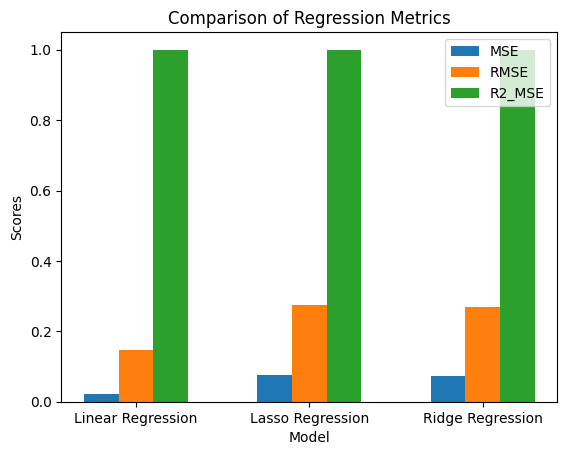

In [ ]:
#plot
import matplotlib.pyplot as plt
import numpy as np

mse = [mse1, mse2, mse3]
rmse = [rmse1, rmse2, rmse3]
r2_mse = [r2_mse1, r2_mse2, r2_mse3]

positions = np.arange(len(mse))
bar_width = 0.2

plt.bar(positions - bar_width, mse, width = bar_width, label = 'MSE')
plt.bar(positions, rmse, width = bar_width, label = 'RMSE')
plt.bar(positions + bar_width, r2_mse, width = bar_width, label = 'R2_MSE')

# adding labels and title
plt.xlabel('Model')
plt.ylabel('Scores')
plt.title('Comparison of Regression Metrics')

# adding the legend
plt.legend()
plt.xticks(positions, ['Linear Regression', 'Lasso Regression', 'Ridge Regression'])
plt.show()

This plot shows that R2_MSE scores the highest, while MSE and RMSE score the lowest for linear regression.

**Franciszek Ostwald - Results Visualization or Printing #############**

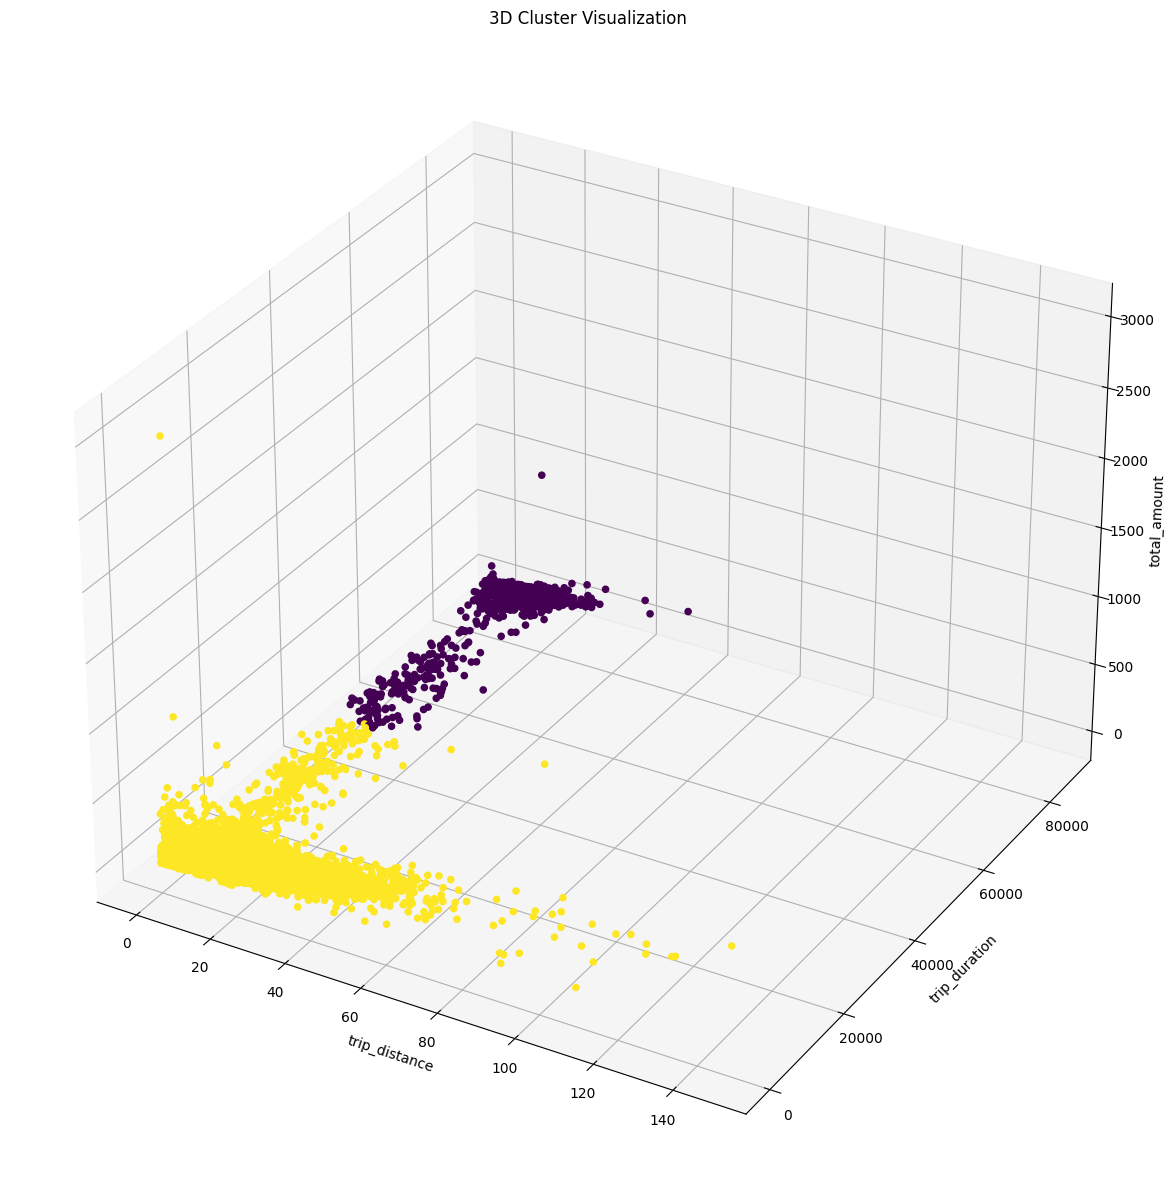

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a new figure with 3D projection
cluster_vis = plt.figure(figsize=(15,15))
ax = cluster_vis.add_subplot(111, projection='3d')

# Scatter plot the data points with cluster labels
ax.scatter(pandas_df1.trip_distance, pandas_df1.trip_duration, pandas_df1.total_amount, c=pandas_df1.prediction, depthshade=False)

# Set labels and title
ax.set_xlabel('trip_distance')
ax.set_ylabel('trip_duration')
ax.set_zlabel('total_amount')
ax.set_title('3D Cluster Visualization')

# Show the plot
plt.show()

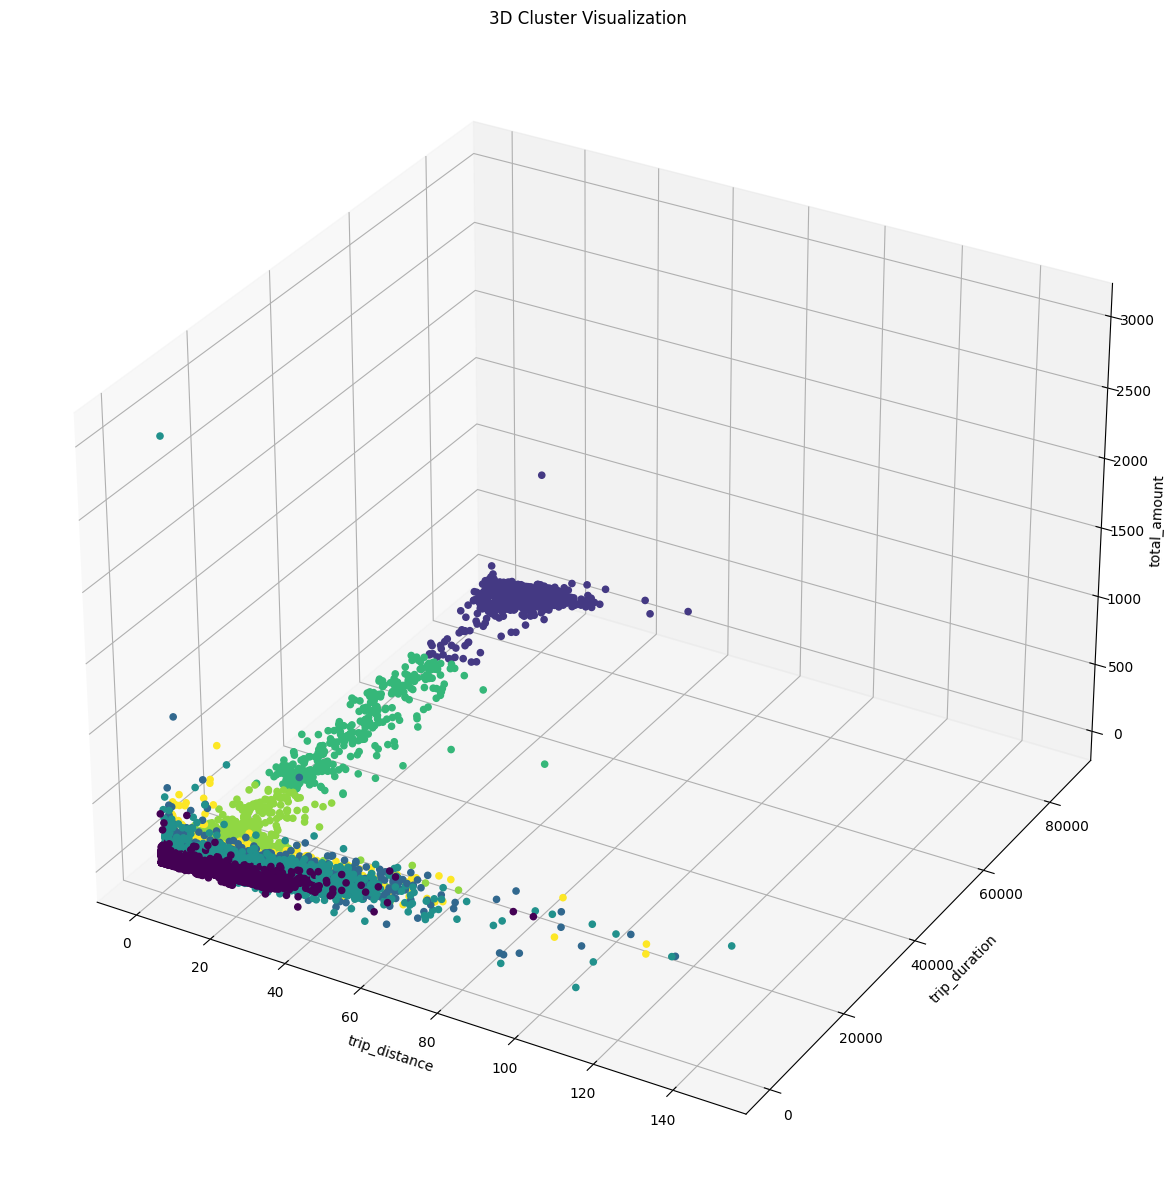

In [ ]:
# Create a new figure with 3D projection
cluster_vis = plt.figure(figsize=(15,15))
ax = cluster_vis.add_subplot(111, projection='3d')

# Scatter plot the data points with cluster labels
ax.scatter(pandas_df2.trip_distance, pandas_df2.trip_duration, pandas_df2.total_amount, c=pandas_df2.prediction, depthshade=False)

# Set labels and title
ax.set_xlabel('trip_distance')
ax.set_ylabel('trip_duration')
ax.set_zlabel('total_amount')
ax.set_title('3D Cluster Visualization')

# Show the plot
plt.show()

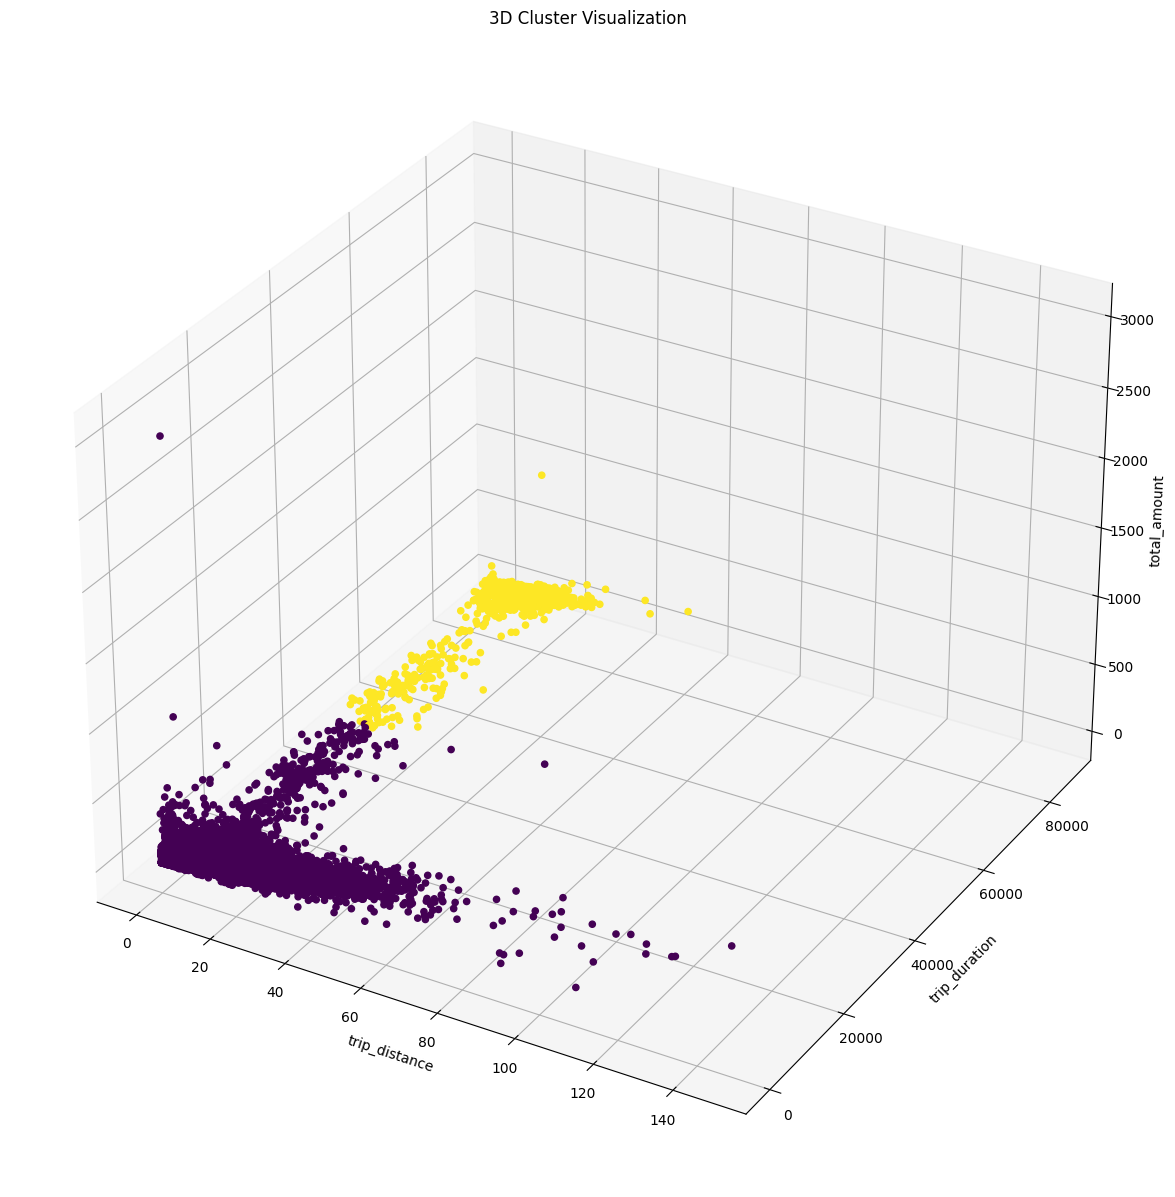

In [ ]:
# Create a new figure with 3D projection
cluster_vis = plt.figure(figsize=(15,15))
ax = cluster_vis.add_subplot(111, projection='3d')

# Scatter plot the data points with cluster labels
ax.scatter(pandas_df3.trip_distance, pandas_df3.trip_duration, pandas_df3.total_amount, c=pandas_df3.prediction, depthshade=False)

# Set labels and title
ax.set_xlabel('trip_distance')
ax.set_ylabel('trip_duration')
ax.set_zlabel('total_amount')
ax.set_title('3D Cluster Visualization')

# Show the plot
plt.show()

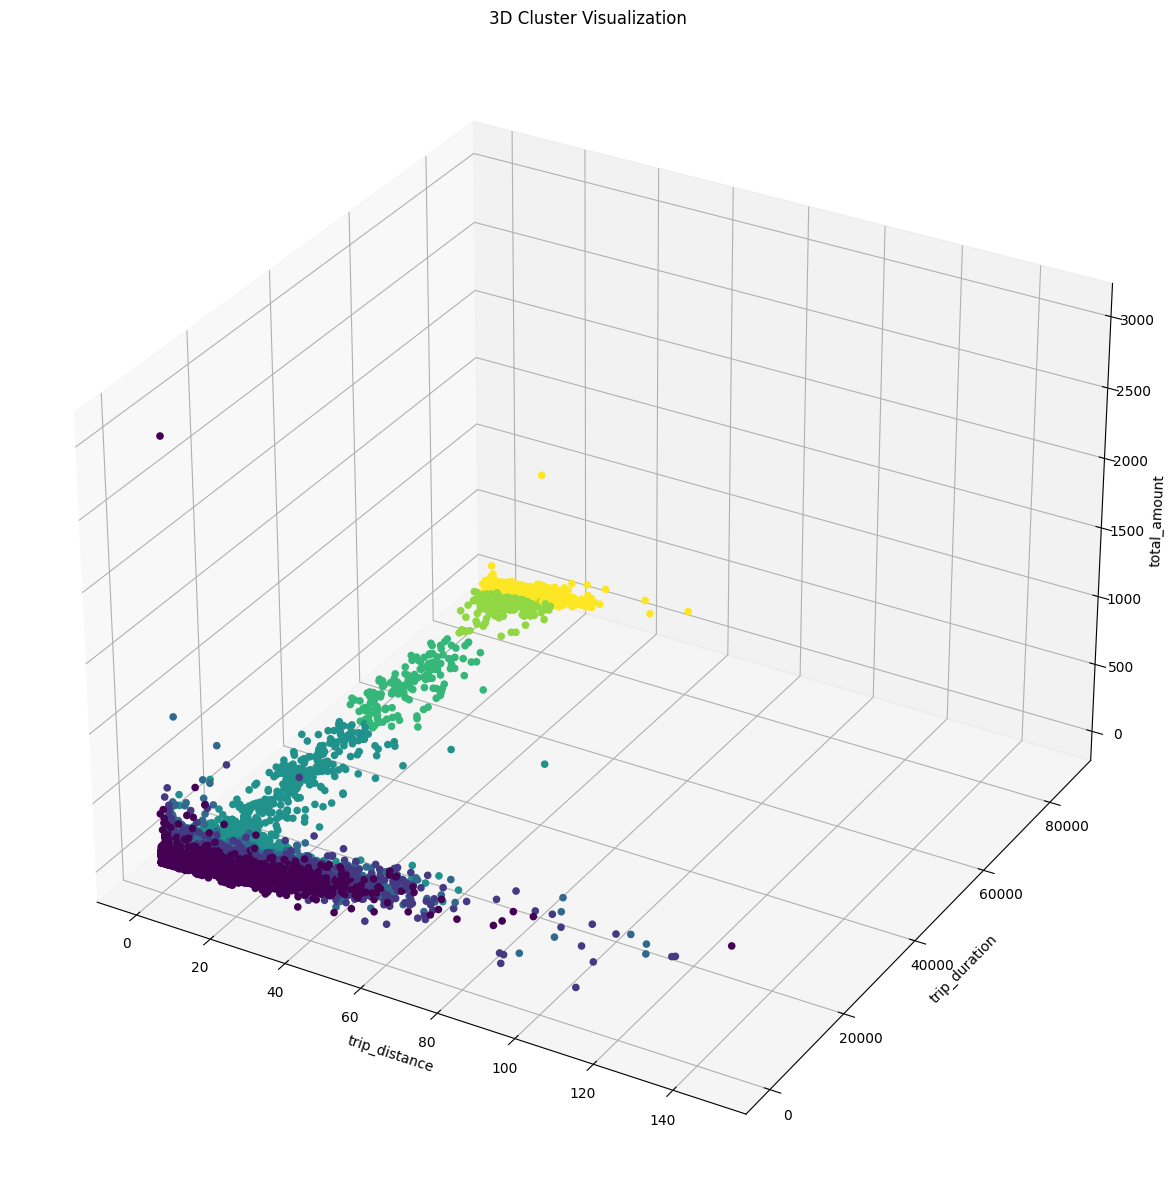

In [ ]:
# Create a new figure with 3D projection
cluster_vis = plt.figure(figsize=(15,15))
ax = cluster_vis.add_subplot(111, projection='3d')

# Scatter plot the data points with cluster labels
ax.scatter(pandas_df4.trip_distance, pandas_df4.trip_duration, pandas_df4.total_amount, c=pandas_df4.prediction, depthshade=False)

# Set labels and title
ax.set_xlabel('trip_distance')
ax.set_ylabel('trip_duration')
ax.set_zlabel('total_amount')
ax.set_title('3D Cluster Visualization')

# Show the plot
plt.show()

---
# **Task 6 - LSEP Considerations (5 marks)**
---

**Jadyn Vigil: Ethics**

Using a specified dataset and applying deep learning models to predict an outcome may encounter ethical issues. The ethical implications of the chosen data set, NYC Taxi Data, is that the data does not include cash tips which could lead to a bias in data and not accurately represent the total amount paid. The dataset also may not represent certain areas of New York City due to those areas not being covered by taxis or a limit of the amount of taxis that pick up passengers in that area. There are also privacy concerns in the dataset because passengers may not have given consent to their personal routes being recorded and used by the public. Mitigation strategies that could help improve the ethical implications of using NYC Taxi data is to include sampling data from all areas of NYC, even if that area has very little data. This will allow for sampling to be more representative of the city. Another mitigation strategy that may be useful could be letting passengers know that their route data may be used for educational purposes and allowing them the opportunity to decline.

# Student 1: **Type the chosen issue**

add contribution here ...

# Student 2: **Type the chosen issue**

add contribution here ...

# Student 3: **Type the chosen issue**

add contribution here ...

---

# **Task 7 - Convert ipynb to HTML for Turnitin submission [5 marks]**

---



In [ ]:
# install nbconvert (if facing the conversion error)
!pip3 install nbconvert

In [ ]:
# convert ipynb to html and submit this HTML file
!jupyter nbconvert --to html Your_Group_ID_CRWK_CN7030.ipynb